In [12]:
import sys
import math
import matplotlib.pyplot as plt
import pandas as pd
import heapq
import time



In [13]:
def ler_tsp_arquivo(caminho_arquivo):
    coords = []
    lendo = False

    with open(caminho_arquivo, 'r') as f:
        for linha in f:
            linha = linha.strip()

            if linha == "NODE_COORD_SECTION":
                lendo = True
                continue

            if linha == "EOF":
                break

            if lendo:
                partes = linha.split()
                id = int(partes[0])
                x = float(partes[1])
                y = float(partes[2])
                coords.append((id, x, y))

    return coords

def calcular_distancia(cidade1, cidade2):
    _, xi, yi = cidade1
    _, xj, yj = cidade2

    dist = math.sqrt((xi - xj)**2 + (yi - yj)**2)
    return math.floor(0.5 + dist)

def criar_matriz_distancias(coords):
    n = len(coords)

    matriz = [[0 for _ in range(n)] for _ in range(n)]

    for i in range(n):
        for j in range(n):
            if i != j:
                matriz[i][j] = calcular_distancia(coords[i], coords[j])

    return matriz


In [14]:
#plotar grafico
def preparar_coords(coords):
    return {int(id_): (x, y) for id_, x, y in coords}


def configurar_plot(titulo):
    plt.figure(figsize=(18, 8))
    plt.title(titulo, fontsize=16)
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.grid(True, alpha=0.3)


def desenhar_vertices(coords_dict):
    for vertice, (x, y) in coords_dict.items():
        plt.scatter(x, y, s=90, zorder=3)
        plt.text(
            x,
            y,
            str(vertice),
            fontsize=12,
            verticalalignment="bottom",
            horizontalalignment="right",
            zorder=4
        )


def desenhar_aresta(coords_dict, u, v, peso=None, mostrar_peso=True, linewidth=2, alpha=1):
    x1, y1 = coords_dict[u]
    x2, y2 = coords_dict[v]

    plt.plot(
        [x1, x2],
        [y1, y2],
        linewidth=linewidth,
        alpha=alpha,
        zorder=1
    )

    if mostrar_peso and peso is not None:
        xm = (x1 + x2) / 2
        ym = (y1 + y2) / 2

        plt.text(
            xm,
            ym,
            str(peso),
            fontsize=9,
            zorder=2
        )


def plotar_agm(coords, agm, titulo, custo):
    coords_dict = preparar_coords(coords)

    configurar_plot(f"{titulo} - Custo: {custo:.2f}")

    for peso, vertice, pai in agm:
        desenhar_aresta(
            coords_dict,
            pai,
            vertice,
            peso=peso,
            mostrar_peso=True,
            linewidth=2,
            alpha=1
        )

    desenhar_vertices(coords_dict)
    plt.show()


def plotar_grafo(coords, matriz):
    coords_dict = preparar_coords(coords)
    n = len(coords)

    configurar_plot("Grafo Completo")

    for i in range(1, n + 1):
        for j in range(i + 1, n + 1):
            peso = matriz[i - 1][j - 1]

            if peso != 0:
                desenhar_aresta(
                    coords_dict,
                    i,
                    j,
                    peso=peso,
                    mostrar_peso=True,
                    linewidth=1,
                    alpha=0.25
                )

    desenhar_vertices(coords_dict)
    plt.show()


def plotar_ciclo(coords, ciclo, custo, matriz, titulo="Ciclo Hamiltoniano"):
    coords_dict = preparar_coords(coords)

    configurar_plot(f"{titulo} - Custo: {custo:.2f}")

    for i in range(len(ciclo) - 1):
        u = ciclo[i]
        v = ciclo[i + 1]

        peso = matriz[u - 1][v - 1]

        desenhar_aresta(
            coords_dict,
            u,
            v,
            peso=peso,
            mostrar_peso=True,
            linewidth=2,
            alpha=1
        )

    desenhar_vertices(coords_dict)
    plt.show()


def plotar_tour(coords, tour, titulo="Tour"):
    coords_dict = preparar_coords(coords)

    configurar_plot(titulo)

    for i in range(len(tour) - 1):
        u = tour[i]
        v = tour[i + 1]

        desenhar_aresta(
            coords_dict,
            u,
            v,
            peso=None,
            mostrar_peso=False,
            linewidth=2,
            alpha=1
        )

    desenhar_vertices(coords_dict)
    plt.show()

In [15]:
def kruskal_agm(grafo):
    n = len(grafo)

    agm = []
    tupla = []
    custo_total = 0

    for i in range(n):
        for j in range(i + 1, n):
            peso = grafo[i][j]

            if peso != 0:
                tupla.append((peso, i, j))

    tupla_ordenada = sorted(tupla, key=lambda x: x[0])

    pai = list(range(n))

    def find(v):
        if pai[v] != v:
            pai[v] = find(pai[v])
        return pai[v]

    def union(origem, destino):
        raiz_origem = find(origem)
        raiz_destino = find(destino)

        if raiz_origem != raiz_destino:
            pai[raiz_destino] = raiz_origem
            return True

        return False

    for peso, origem, destino in tupla_ordenada:
        if union(origem, destino):
            agm.append((peso, origem + 1, destino + 1))
            custo_total += peso

        if len(agm) == n - 1:
            break

    return agm, custo_total
    


In [16]:
#prim
class Grafo:
    def __init__(self):
        self.adj = {}

    def adicionar_aresta(self, u, v, peso):
        if u not in self.adj: self.adj[u] = {}
        if v not in self.adj: self.adj[v] = {}

        self.adj[u][v] = peso
        self.adj[v][u] = peso

def converter_retorno_prim(arestas_prim, matriz_distancias):
    arestas_convertidas = []

    for aresta in arestas_prim:
        # Separa a string "0-1"
        origem, destino = map(int, aresta.split("-"))

        # Obtém o peso da aresta na matriz de distâncias
        peso = matriz_distancias[origem][destino]

        # Converte os vértices de 0...n-1 para 1...n
        arestas_convertidas.append(
            (peso, origem + 1, destino + 1)
        )

    return arestas_convertidas


def algoritmo_prim(grafo, raiz):
    chaves = {v: float('inf') for v in grafo.adj}
    chaves[raiz] = 0
    
    pais = {v: None for v in grafo.adj}
    
    fila_T = [(0, raiz)]
    visitados = set()
    agm = []
    peso_total = 0

    while fila_T:
        peso_u, u = heapq.heappop(fila_T)
        
        if u in visitados:
            continue
            
        visitados.add(u)
        
        if pais[u] is not None:
            agm.append(f"{pais[u]}-{u}")
            peso_total += peso_u

        for s, peso_us in grafo.adj[u].items():
            if s not in visitados and peso_us < chaves[s]:
                chaves[s] = peso_us
                pais[s] = u
                heapq.heappush(fila_T, (peso_us, s))
                
    return agm, peso_total


Tempo de execução do Prim  : 0.00181580s
Tempo de execução do Kruskal  : 0.00239170s


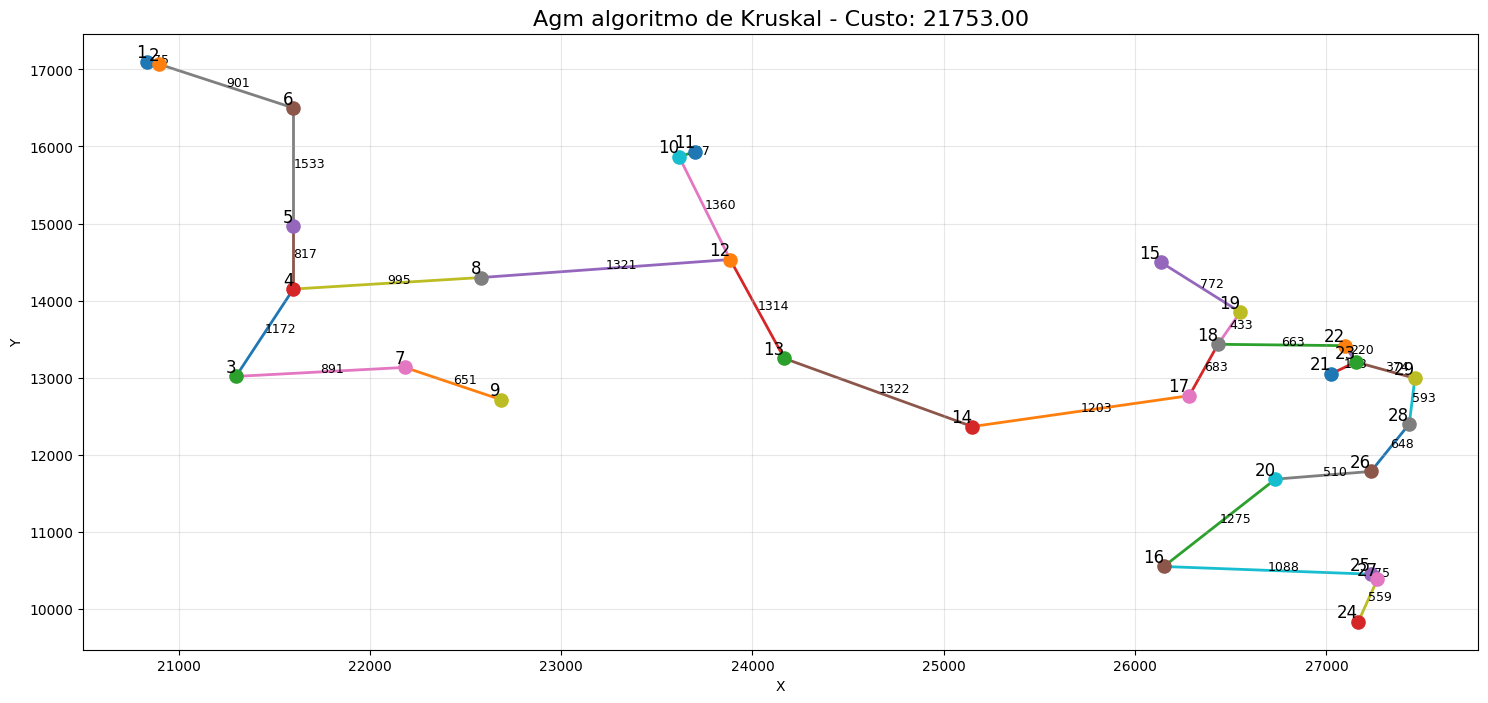

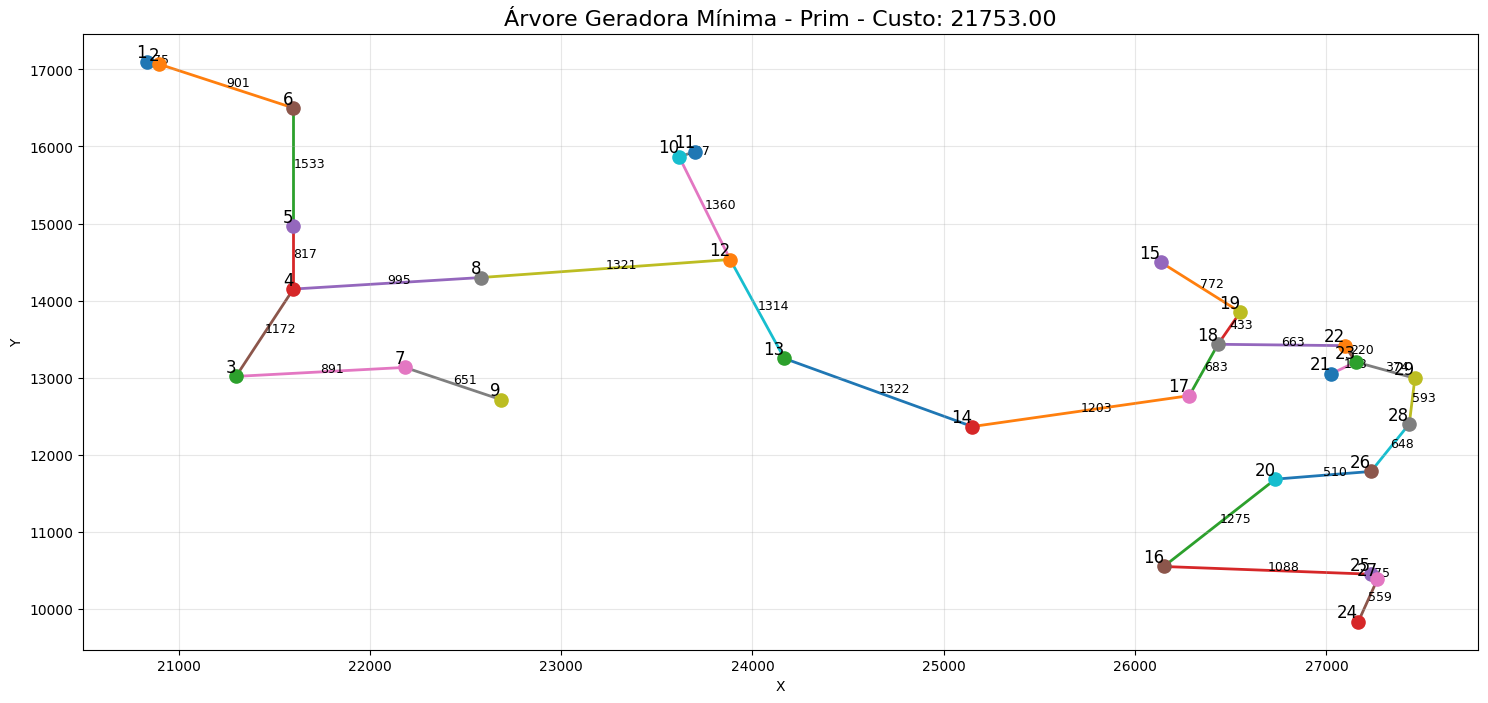

Custo Prim: 21753
Custo Kruskal: 21753


In [17]:
instancia = 'instancias/tsp29.tsp'
coords = ler_tsp_arquivo(instancia)
matriz = criar_matriz_distancias(coords)

if matriz:
    V = len(matriz)
    g_numerico = Grafo()
    
    for i in range(V):
        for j in range(i + 1, V): 
            peso = matriz[i][j]
            if peso > 0: 
                g_numerico.adicionar_aresta(i, j, peso)


inicio_prim = time.perf_counter()

agm_prim, custo_total_prim = algoritmo_prim(g_numerico, raiz=0)

fim_prim = time.perf_counter()

print(f"Tempo de execução do Prim  : {fim_prim - inicio_prim:.8f}s")

inicio_kruskal = time.perf_counter()

agm_kruskal, custo_total_kruskal = kruskal_agm(matriz)

fim_kruskal = time.perf_counter()

print(f"Tempo de execução do Kruskal  : {fim_kruskal - inicio_kruskal:.8f}s")


agm_prim_convertida = converter_retorno_prim( agm_prim, matriz)


plotar_agm(coords,agm_kruskal,"Agm algoritmo de Kruskal", custo_total_kruskal)


plotar_agm(coords, agm_prim_convertida, "Árvore Geradora Mínima - Prim", custo_total_prim)

print("Custo Prim:", custo_total_prim)
print("Custo Kruskal:", custo_total_kruskal)


In [18]:
import time
import pandas as pd

instancias = [
    'instancias/tsp10.tsp',
    'instancias/tsp29.tsp',
    'instancias/tsp38.tsp',
    'instancias/tsp51.tsp',
    'instancias/tsp100.tsp',
    'instancias/tsp150.tsp',
    'instancias/tsp436.tsp'
]

resultados = []

for instancia in instancias:

    coords = ler_tsp_arquivo(instancia)
    matriz = criar_matriz_distancias(coords)

    V = len(matriz)

    g_numerico = Grafo()

    for i in range(V):
        for j in range(i + 1, V):
            peso = matriz[i][j]
            if peso > 0:
                g_numerico.adicionar_aresta(i, j, peso)

    inicio_prim = time.perf_counter()
    agm_prim, custo_total_prim = algoritmo_prim(g_numerico, raiz=0)
    fim_prim = time.perf_counter()

    inicio_kruskal = time.perf_counter()
    agm_kruskal, custo_total_kruskal = kruskal_agm(matriz)
    fim_kruskal = time.perf_counter()

    resultados.append([
        instancia.split('/')[-1],
        V,
        fim_prim - inicio_prim,
        fim_kruskal - inicio_kruskal,
        custo_total_prim,
        custo_total_kruskal
    ])

df = pd.DataFrame(
    resultados,
    columns=[
        "Instância",
        "Vértices",
        "Tempo Prim",
        "Tempo Kruskal",
        "Custo Prim",
        "Custo Kruskal"
    ]
)

df

,Instância,Vértices,Tempo Prim,Tempo Kruskal,Custo Prim,Custo Kruskal
0,tsp10.tsp,6,0.000033,0.000020,4498,4498
1,tsp29.tsp,29,0.000310,0.001352,21753,21753
2,tsp38.tsp,38,0.000459,0.001262,5828,5828
3,tsp51.tsp,51,0.000304,0.000774,375,375
4,tsp100.tsp,100,0.002084,0.003231,18402,18402
5,tsp150.tsp,150,0.003980,0.009408,5878,5878
6,tsp436.tsp,436,0.024634,0.045019,1269,1269


In [22]:
import statistics
import time
import pandas as pd


instancias = [
    'instancias/tsp100.tsp',
    'instancias/tsp150.tsp',
    'instancias/tsp436.tsp',
    'instancias/tsp500.tsp',
    'instancias/tsp1000.tsp',
    'instancias/tsp2000.tsp'
]

resultados = []

for instancia in instancias:

    coords = ler_tsp_arquivo(instancia)
    matriz = criar_matriz_distancias(coords)

    V = len(matriz)

    g_numerico = Grafo()

    for i in range(V):
        for j in range(i + 1, V):
            peso = matriz[i][j]
            if peso > 0:
                g_numerico.adicionar_aresta(i, j, peso)

    tempos_prim = []
    tempos_kruskal = []

    for _ in range(10):

        inicio = time.perf_counter()
        agm_prim, custo_total_prim = algoritmo_prim(g_numerico, raiz=0)
        fim = time.perf_counter()

        tempos_prim.append(fim - inicio)

        inicio = time.perf_counter()
        agm_kruskal, custo_total_kruskal = kruskal_agm(matriz)
        fim = time.perf_counter()

        tempos_kruskal.append(fim - inicio)

    resultados.append([
        instancia.split('/')[-1],
        V,
        statistics.mean(tempos_prim),
        statistics.stdev(tempos_prim),
        statistics.mean(tempos_kruskal),
        statistics.stdev(tempos_kruskal),
        custo_total_prim,
        custo_total_kruskal
    ])

df_final = pd.DataFrame(
    resultados,
    columns=[
        "Instância",
        "Vértices",
        "Média Prim",
        "DP Prim",
        "Média Kruskal",
        "DP Kruskal",
        "Custo Prim",
        "Custo Kruskal"
    ]
)

df_final

,Instância,Vértices,Média Prim,DP Prim,Média Kruskal,DP Kruskal,Custo Prim,Custo Kruskal
0,tsp100.tsp,100,0.001331,0.000354,0.001795,0.001615,18402,18402
1,tsp150.tsp,150,0.003615,0.000993,0.003942,0.000997,5878,5878
2,tsp436.tsp,436,0.021868,0.004347,0.027562,0.004018,1269,1269
3,tsp500.tsp,500,0.039998,0.005997,0.052435,0.004191,147561,147561
4,tsp1000.tsp,1000,0.179916,0.017001,0.241286,0.020929,210473,210473
5,tsp2000.tsp,2000,0.726127,0.054181,0.978350,0.069743,293889,293889


In [23]:
import statistics
import time
import pandas as pd

instancias = [
    'instancias/tsp100.tsp',
    'instancias/tsp150.tsp',
    'instancias/tsp436.tsp',
    'instancias/tsp500.tsp',
    'instancias/tsp1000.tsp',
    'instancias/tsp2000.tsp'
]

resultados = []

for instancia in instancias:

    tempos_construcao = []
    tempos_prim = []
    tempos_kruskal = []

    for _ in range(10):

        # --------------------
        # CONSTRUÇÃO
        # --------------------
        inicio = time.perf_counter()

        coords = ler_tsp_arquivo(instancia)
        matriz = criar_matriz_distancias(coords)

        V = len(matriz)

        g_numerico = Grafo()

        for i in range(V):
            for j in range(i + 1, V):
                peso = matriz[i][j]
                if peso > 0:
                    g_numerico.adicionar_aresta(i, j, peso)

        fim = time.perf_counter()

        tempos_construcao.append(fim - inicio)

        # --------------------
        # PRIM
        # --------------------
        inicio = time.perf_counter()

        agm_prim, custo_total_prim = algoritmo_prim(
            g_numerico,
            raiz=0
        )

        fim = time.perf_counter()

        tempos_prim.append(fim - inicio)

        # --------------------
        # KRUSKAL
        # --------------------
        inicio = time.perf_counter()

        agm_kruskal, custo_total_kruskal = kruskal_agm(
            matriz
        )

        fim = time.perf_counter()

        tempos_kruskal.append(fim - inicio)

    resultados.append([
        instancia.split('/')[-1],
        V,

        statistics.mean(tempos_construcao),
        statistics.stdev(tempos_construcao),

        statistics.mean(tempos_prim),
        statistics.stdev(tempos_prim),

        statistics.mean(tempos_kruskal),
        statistics.stdev(tempos_kruskal),

        custo_total_prim,
        custo_total_kruskal
    ])

df_final = pd.DataFrame(
    resultados,
    columns=[
        "Instância",
        "Vértices",

        "Média Construção",
        "DP Construção",

        "Média Prim",
        "DP Prim",

        "Média Kruskal",
        "DP Kruskal",

        "Custo Prim",
        "Custo Kruskal"
    ]
)

df_final

,Instância,Vértices,Média Construção,DP Construção,Média Prim,DP Prim,Média Kruskal,DP Kruskal,Custo Prim,Custo Kruskal
0,tsp100.tsp,100,0.122792,0.365113,0.002490,0.002180,0.002950,0.004236,18402,18402
1,tsp150.tsp,150,0.014043,0.000742,0.003728,0.000902,0.003727,0.000653,5878,5878
2,tsp436.tsp,436,0.111915,0.010065,0.021941,0.003261,0.027629,0.004081,1269,1269
3,tsp500.tsp,500,0.141409,0.005983,0.037298,0.001246,0.049166,0.004189,147561,147561
4,tsp1000.tsp,1000,0.598948,0.048448,0.189052,0.028631,0.251020,0.029661,210473,210473
5,tsp2000.tsp,2000,2.395847,0.118125,0.832605,0.075751,0.989114,0.084538,293889,293889


In [26]:
import random

def gerar_grafo_esparso(n):

    matriz = [[0]*n for _ in range(n)]

    # garante conectividade

    for i in range(n-1):

        peso = random.randint(1,100)

        matriz[i][i+1] = peso
        matriz[i+1][i] = peso

    # poucas arestas extras

    extras = n // 5

    for _ in range(extras):

        u = random.randint(0,n-1)
        v = random.randint(0,n-1)

        if u != v and matriz[u][v] == 0:

            peso = random.randint(1,100)

            matriz[u][v] = peso
            matriz[v][u] = peso

    return matriz

In [27]:
matriz_esparsa = gerar_grafo_esparso(100)

print("Vértices:", len(matriz_esparsa))

Vértices: 100


In [28]:
import statistics
import time

tamanhos = [100, 500, 1000, 2000]

resultados_esparsos = []

for n in tamanhos:

    tempos_prim = []
    tempos_kruskal = []

    for _ in range(10):

        matriz = gerar_grafo_esparso(n)

        g_numerico = Grafo()

        for i in range(n):
            for j in range(i + 1, n):
                if matriz[i][j] > 0:
                    g_numerico.adicionar_aresta(i, j, matriz[i][j])

        inicio = time.perf_counter()
        agm_prim, custo_prim = algoritmo_prim(g_numerico, raiz=0)
        fim = time.perf_counter()

        tempos_prim.append(fim - inicio)

        inicio = time.perf_counter()
        agm_kruskal, custo_kruskal = kruskal_agm(matriz)
        fim = time.perf_counter()

        tempos_kruskal.append(fim - inicio)

    resultados_esparsos.append([
        n,
        statistics.mean(tempos_prim),
        statistics.stdev(tempos_prim),
        statistics.mean(tempos_kruskal),
        statistics.stdev(tempos_kruskal)
    ])

df_esparso = pd.DataFrame(
    resultados_esparsos,
    columns=[
        "Vértices",
        "Média Prim",
        "DP Prim",
        "Média Kruskal",
        "DP Kruskal"
    ]
)

df_esparso

,Vértices,Média Prim,DP Prim,Média Kruskal,DP Kruskal
0,100,0.001460,0.004106,0.000636,0.001176
1,500,0.001047,0.000526,0.004800,0.000340
2,1000,0.001800,0.000331,0.018997,0.000808
3,2000,0.004297,0.000604,0.075618,0.003349


In [29]:
import random

def gerar_grafo_denso(n):

    matriz = [[0]*n for _ in range(n)]

    for i in range(n):
        for j in range(i + 1, n):

            peso = random.randint(1,100)

            matriz[i][j] = peso
            matriz[j][i] = peso

    return matriz

In [30]:
import statistics
import time

tamanhos = [100, 500, 1000]

resultados_densos = []

for n in tamanhos:

    tempos_prim = []
    tempos_kruskal = []

    for _ in range(10):

        matriz = gerar_grafo_denso(n)

        g_numerico = Grafo()

        for i in range(n):
            for j in range(i + 1, n):
                g_numerico.adicionar_aresta(
                    i,
                    j,
                    matriz[i][j]
                )

        inicio = time.perf_counter()

        agm_prim, custo_prim = algoritmo_prim(
            g_numerico,
            raiz=0
        )

        fim = time.perf_counter()

        tempos_prim.append(fim - inicio)

        inicio = time.perf_counter()

        agm_kruskal, custo_kruskal = kruskal_agm(
            matriz
        )

        fim = time.perf_counter()

        tempos_kruskal.append(fim - inicio)

    resultados_densos.append([
        n,
        statistics.mean(tempos_prim),
        statistics.stdev(tempos_prim),
        statistics.mean(tempos_kruskal),
        statistics.stdev(tempos_kruskal)
    ])

df_denso = pd.DataFrame(
    resultados_densos,
    columns=[
        "Vértices",
        "Média Prim",
        "DP Prim",
        "Média Kruskal",
        "DP Kruskal"
    ]
)

df_denso

,Vértices,Média Prim,DP Prim,Média Kruskal,DP Kruskal
0,100,0.000831,0.000267,0.001277,0.000450
1,500,0.015307,0.001855,0.039791,0.003561
2,1000,0.064884,0.014093,0.201546,0.044012


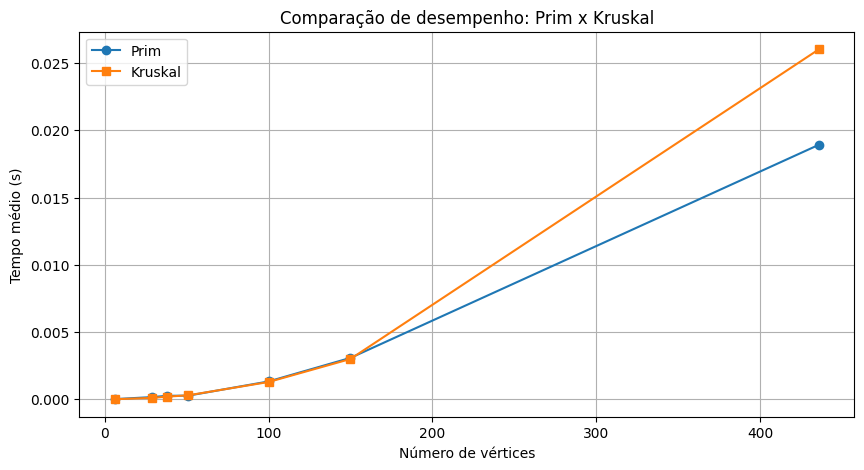

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    df_final["Vértices"],
    df_final["Média Prim"],
    marker='o',
    label='Prim'
)

plt.plot(
    df_final["Vértices"],
    df_final["Média Kruskal"],
    marker='s',
    label='Kruskal'
)

plt.xlabel("Número de vértices")
plt.ylabel("Tempo médio (s)")
plt.title("Comparação de desempenho: Prim x Kruskal")

plt.grid(True)
plt.legend()

plt.show()

In [21]:
df_final.to_csv("resultados_agm.csv", index=False)